In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

In [ ]:


data = pd.read_csv("Telco-Customer-Churn.csv")

print("Shape:", data.shape)
data.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

data = data.drop(columns=['customerID'])

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

data = data.dropna()

data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:

data_encoded = pd.get_dummies(data, drop_first=True)

print("Encoded shape:", data_encoded.shape)

Encoded shape: (7032, 31)


In [ ]:

X = data_encoded.drop('Churn', axis=1)
y = data_encoded['Churn']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

In [ ]:

sm = SMOTE(random_state=1)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_bal.value_counts())

After SMOTE: Churn
0    3872
1    3872
Name: count, dtype: int64


In [ ]:

rf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=1)
rf.fit(X_train_bal, y_train_bal)

y_pred_initial = rf.predict(X_test)

print("Initial Accuracy:", accuracy_score(y_test, y_pred_initial))

Initial Accuracy: 0.770193401592719


In [ ]:

print("Train Score:", rf.score(X_train_bal, y_train_bal))
print("Test Score:", rf.score(X_test, y_test))

Train Score: 0.8542097107438017
Test Score: 0.770193401592719


In [ ]:

param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

rf_random.fit(X_train_bal, y_train_bal)

print("Best Parameters:", rf_random.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': None}


In [ ]:

final_rf = rf_random.best_estimator_

y_pred = final_rf.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.7758816837315131


In [ ]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1291
           1       0.57      0.60      0.59       467

    accuracy                           0.78      1758
   macro avg       0.71      0.72      0.72      1758
weighted avg       0.78      0.78      0.78      1758



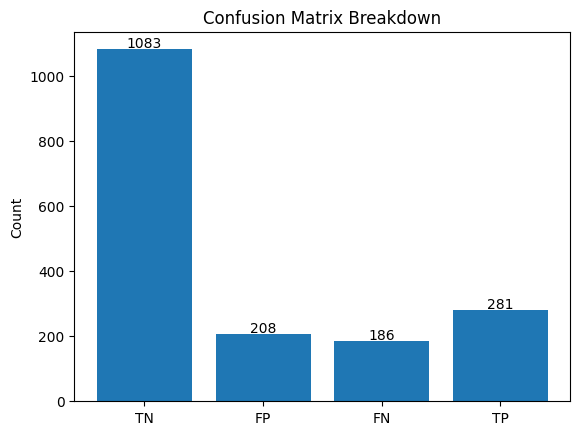

In [26]:
cmatrix = confusion_matrix(y_test, y_pred)

labels = ['TN', 'FP', 'FN', 'TP']
values = [cmatrix[0,0], cmatrix[0,1], cmatrix[1,0], cmatrix[1,1]]

plt.bar(labels, values)

plt.title("Confusion Matrix Breakdown")
plt.ylabel("Count")

for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

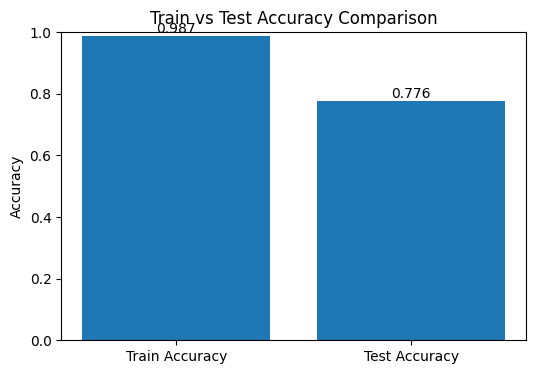

In [16]:

train_acc = final_rf.score(X_train_bal, y_train_bal)
test_acc = final_rf.score(X_test, y_test)

labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc, test_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Train vs Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

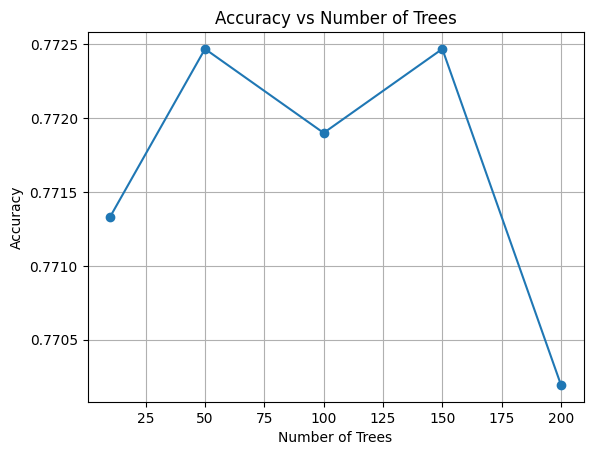

In [17]:

tree_range = [10, 50, 100, 150, 200]
test_scores = []

for n in tree_range:
    temp_model = RandomForestClassifier(n_estimators=n, random_state=1)
    temp_model.fit(X_train_bal, y_train_bal)
    preds = temp_model.predict(X_test)
    test_scores.append(accuracy_score(y_test, preds))

plt.plot(tree_range, test_scores, marker='o')

plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

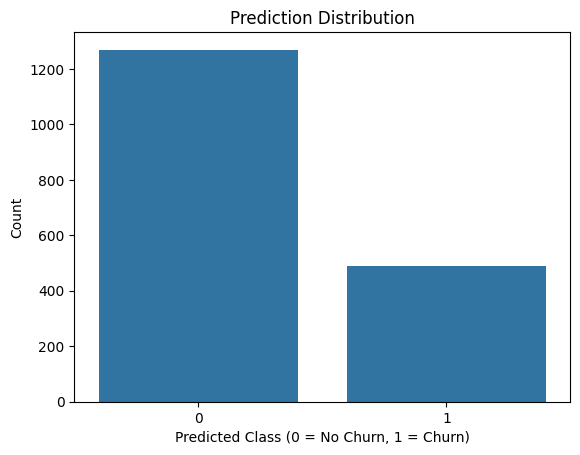

In [19]:

sns.countplot(x=y_pred)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class (0 = No Churn, 1 = Churn)")
plt.ylabel("Count")

plt.show()

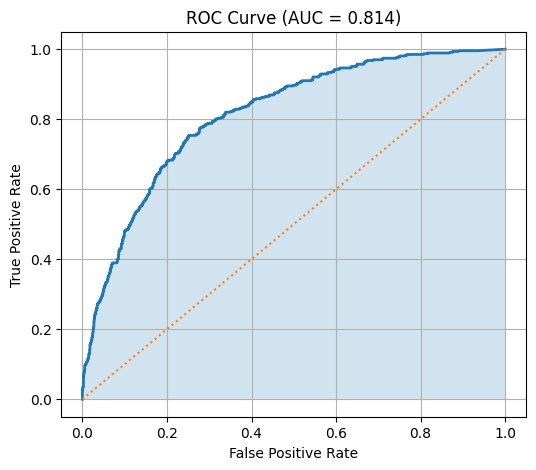

In [33]:
y_scores = final_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_scores)
auc_val = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2)
plt.fill_between(fpr, tpr, alpha=0.2)

plt.plot([0,1], [0,1], linestyle=':')

plt.title(f"ROC Curve (AUC = {auc_val:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid()
plt.show()

tenure                            0.166396
TotalCharges                      0.156537
MonthlyCharges                    0.117936
PaymentMethod_Electronic check    0.098755
InternetService_Fiber optic       0.067926
Contract_Two year                 0.052197
PaperlessBilling_Yes              0.041442
Contract_One year                 0.023949
MultipleLines_Yes                 0.021075
StreamingMovies_Yes               0.020950
dtype: float64


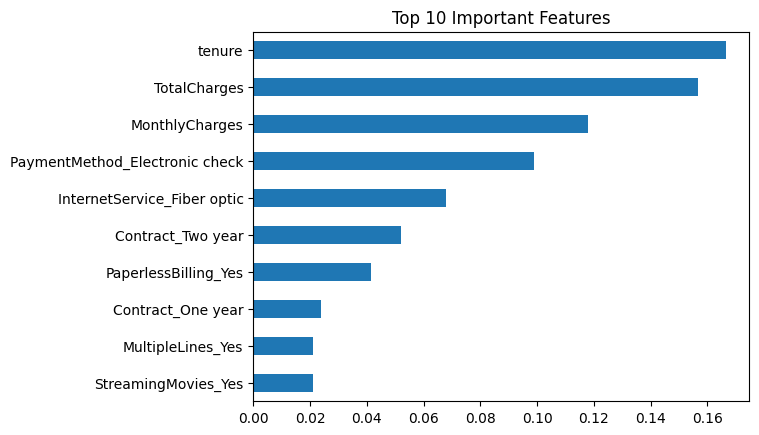

In [ ]:

importances = pd.Series(final_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

print(top_features)

top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

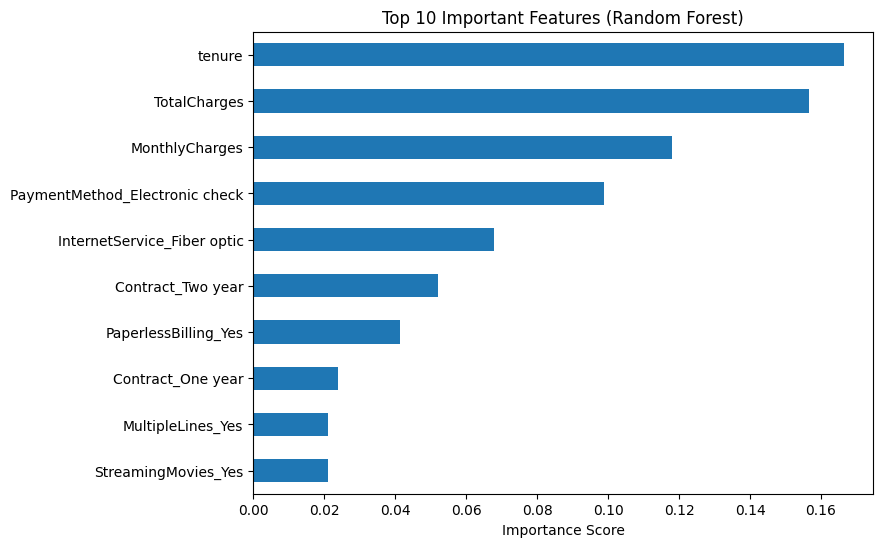

In [ ]:

importances = pd.Series(final_rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(8,6))
top10.plot(kind='barh')

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

In [ ]:

comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison_df.head(20)

,Actual,Predicted
0,1,0
1,0,1
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,0,0
9,1,0
